In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語フォント対応
import seaborn as sns

In [2]:
# df.to_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_setai_over2_monthly.csv', index=False)
df_share = pd.read_csv('/Users/balalala/Documents/GitHub/Consumption_Data/Data_time_series/en_share_over2_monthly.csv')

In [3]:
# Filter for rows where Medium (中分類) and Minor (小分類) are '-'
# This isolates the top-level "Major" rows

major_rows = df_share[ (df_share['Category level 1'] != '-') & (df_share['Category level 2'] == '-') & (df_share['Category level 3'] == '-') ]

major_dict = dict(zip(major_rows['Category level 1'], major_rows['Item']))
print(major_dict['1']) # Output: 食料

hierarchy = {}

# Iterate through every row
for index, row in df_share.iterrows():
    major_id = row['Category level 1']
    med_id = row['Category level 2']
    min_id = row['Category level 3']
    name = row['Item']

    # Skip header/garbage rows if any
    if major_id == '-': continue 

    # 1. Initialize Major Level
    # We use the ID as the key, but store the Name inside
    if major_id not in hierarchy:
        # Look up the major name from our simple dict
        major_name = major_dict.get(major_id, "他")
        hierarchy[major_id] = {'name': major_name, 'med': {}}

    # 2. Add Medium Level (if this row represents a Medium category or deeper)
    if med_id != '-':
        if med_id not in hierarchy[major_id]['med']:
             # Use the name if this is the defining row, otherwise generic placeholder until found
            hierarchy[major_id]['med'][med_id] = {'name': name, 'small': {}}
        
        # Update name if this is exactly the Medium definition row
        if min_id == '-':
            hierarchy[major_id]['med'][med_id]['name'] = name

    # 3. Add Minor Level (if this row represents a Minor category)
    if min_id != '-':
        # Add the minor category to the medium's children
        hierarchy[major_id]['med'][med_id]['small'][min_id] = name
# Usage:
# hierarchy[1]['children'][1]['name']  -> Access the name of Medium Category 1 inside Major 1
# Initialize the flat dictionary
# Key = Item Name (e.g., 'パン'), Value = Formatted String (e.g., '食料ーパン')

name_to_path_map = {}

# Iterate through the hierarchy
for major_id, major_data in hierarchy.items():
    major_name = major_data['name']
    
    # 1. Add the Major category itself (Optional, if needed)
    # name_to_path_map[major_name] = major_name
    
    # Check if 'med' exists
    if 'med' in major_data:
        for med_id, med_data in major_data['med'].items():
            med_name = med_data['name']
            
            # 2. Add Medium Category: Input '穀類' -> Output '食料ー穀類'
            name_to_path_map[med_name] = f"{major_name}ー{med_name}"
            
            # Check if 'small' exists
            if 'small' in med_data:
                for small_id, small_name in med_data['small'].items():
                    # 3. Add Small Category: Input 'パン' -> Output '食料ーパン'
                    # Note: Using strict user format "Major-Small". 
                    # If you wanted full path "Major-Med-Small", use: f"{major_name}ー{med_name}ー{small_name}"
                    name_to_path_map[small_name] = f"{major_name}ー{med_name}ー{small_name}"

# Check the result
print(name_to_path_map['bread']) 
# Output: '食料ーパン'

def get_category_path(item_name):
    return name_to_path_map.get(item_name, item_name) # Returns "他" if not found

print(get_category_path('bread'))

# --- Step 1: Flatten your hierarchy dictionary ---
# This converts: {'1': {'name': 'food', 'med': {'1': {'name': 'grains', 'small': {'1': 'rice'...
# To: {'rice': 'food', 'bread': 'food', ...}

category_map = {}

for l1_id, l1_info in hierarchy.items():
    l1_name = l1_info['name']
    for l2_id, l2_info in l1_info['med'].items():
        # Option A: Map to Level 1 (Food vs Transport)
        # Option B: Map to Level 2 (Grains vs Meat)
        # Let's map to Level 1 for a high-level systemic view
        for l3_id, l3_name in l2_info['small'].items():
            category_map[l3_name] = l1_name

# Convert to a Series for easy grouping
category_series = pd.Series(category_map)
category_series

food
foodーgrainsーbread
foodーgrainsーbread


rice                                                                        food
bread                                                                       food
noodles                                                                     food
other grains                                                                food
fresh seafood                                                               food
salted and dried seafood                                                    food
Fish paste products                                                         food
Other processed seafood products                                            food
fresh meat                                                                  food
processed meat                                                              food
milk                                                                        food
dairy products                                                              food
egg                         

In [4]:
# Dataframe for 3 levels of category hierarchy

c1 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']=='-') & (df_share['Category level 3']=='-')]

c2 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']=='-')]

c3 = df_share[(df_share['Category level 1']!='-') & (df_share['Category level 2']!='-') & (df_share['Category level 3']!='-')]

In [5]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore

def prep_data_for_stl(raw_df: pd.DataFrame, meta_col_count: int = 3) -> pd.DataFrame:
    """
    Cleans raw DataFrame and transposes it into a Time x Items format.
    """
    # 1. Extract and Transpose
    df_ts = raw_df.set_index('Item').iloc[:, meta_col_count:]
    df_t = df_ts.T

    # 2. Index Formatting
    df_t.index = pd.to_datetime(df_t.index)
    df_t = df_t.sort_index()

    # 3. Type Casting & Handle Missing Data (STL requires no NaNs)
    df_t = df_t.astype(np.float64)
    # df_t = df_t.ffill().bfill() # Forward/backward fill any missing percentages
    
    return df_t

def get_residuals(series: pd.Series, period: int = 12) -> pd.Series:
    """
    Extracts the residual component from a time series using STL.
    """
    # robust=True handles outliers (like COVID-19 anomalies) better
    res = STL(series, period=period, robust=True).fit()
    return res.resid


In [6]:
# STEP 1: Clean and Transpose raw consumption data
df_clean = prep_data_for_stl(c1, meta_col_count=3)

# STEP 2: Apply STL to get the Residuals (Deviations from trend/seasonality)
df_residuals = df_clean.apply(get_residuals, period=12)

# STEP 3: Apply Z-Score Normalization
df_res_norm = df_residuals.apply(zscore)

# STEP 4: Output as Markdown
# Using .to_markdown() converts the dataframe head into a formatted markdown table
markdown_output = df_res_norm.head().to_markdown()
print(markdown_output)
print(df_res_norm.shape)

|                     |         food |   residence |   Utilities/Water |   Furniture/household supplies |   clothing and footwear |   health care |   Transportation/Communication |   education |   educational entertainment |   Other consumption expenditure |
|:--------------------|-------------:|------------:|------------------:|-------------------------------:|------------------------:|--------------:|-------------------------------:|------------:|----------------------------:|--------------------------------:|
| 2000-01-01 00:00:00 |  0.242659    |  0.146333   |        -0.303383  |                     -0.0391812 |                0.760769 |      0.524308 |                     -0.241736  |   0.20041   |                 -0.00815925 |                      -0.0150675 |
| 2000-02-01 00:00:00 | -0.000365243 | -0.0705798  |         0.0480249 |                     -0.334306  |                0.15343  |      0.630427 |                      0.0373436 |  -0.294522  |                  0.370517   

In [7]:
df_clean

Item,food,residence,Utilities/Water,Furniture/household supplies,clothing and footwear,health care,Transportation/Communication,education,educational entertainment,Other consumption expenditure
2000-01-01,23.7645,5.3482,8.0602,3.1668,6.3310,3.5337,10.1369,4.0475,10.2322,25.3791
2000-02-01,25.2213,6.3489,8.8343,3.1679,4.9542,4.0559,10.6794,4.9821,10.2307,21.5249
2000-03-01,23.7746,5.4873,7.5544,3.2960,5.4768,3.5090,11.6589,5.2809,10.7383,23.2241
2000-04-01,23.0688,5.6121,6.8332,2.8773,5.3771,3.3557,12.3349,7.1729,10.1844,23.1839
2000-05-01,26.3850,6.2392,6.8300,3.6543,6.0642,3.6734,11.6957,3.7308,10.9617,20.7661
...,...,...,...,...,...,...,...,...,...,...
2025-07-01,30.6293,6.5834,6.5994,5.2876,3.2840,5.4708,15.2479,2.5918,10.0146,14.2914
2025-08-01,32.6275,6.0243,6.6855,4.4971,2.6648,4.9488,13.5577,2.3511,11.9098,14.7332
2025-09-01,30.7156,5.0565,7.3117,4.0285,2.4171,5.2847,15.5883,4.0189,10.1206,15.4584
2025-10-01,30.7464,5.9598,7.0632,3.8423,3.3085,5.5130,13.8462,4.4246,10.1596,15.1363


In [32]:
import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view


def calculate_relaxation_times(df, threshold_multiplier=1.5):
    """
    Calculate relaxation times (tau) for price shocks across commodity categories.
    
    For each category, identifies shock events where the deviation from a 12-month
    moving average exceeds a threshold, then estimates the exponential decay rate
    back to equilibrium using AR(1) regression.
    
    Parameters
    ----------
    df : pd.DataFrame
        Time series with a datetime column 'Item' (or DatetimeIndex) and
        one column per commodity category.
    threshold_multiplier : float, default 1.5
        Shocks are defined as deviations exceeding
        threshold_multiplier * 1.2 * std(residuals).
    
    Returns
    -------
    pd.DataFrame
        One row per detected shock episode with columns:
        Category, Peak_Date, Return_Date, Peak_Deviation, C_Coefficient,
        Relaxation_Time_tau.
    """
    # --- 0. Preprocessing: ensure DatetimeIndex ---
    if "Item" in df.columns:
        df = df.copy()
        df["Item"] = pd.to_datetime(df["Item"])
        df = df.set_index("Item")

    # --- 1. Compute relative deviation from 12-month centered MA ---
    df_ma = df.rolling(window=12, center=True).mean()
    # Vectorised residual: (actual - MA) / MA
    df_y = df.sub(df_ma).div(df_ma)

    results = []

    for category in df_y.columns:
        y = df_y[category].dropna()
        vals = y.values
        dates = y.index
        n = len(vals)
        if n < 3:
            continue

        # --- 2. Shock threshold ---
        threshold = threshold_multiplier * 1.5 * np.nanstd(vals, ddof=1)
        is_shock = np.abs(vals) > threshold

        # --- 3. State-machine: detect shock peaks and zero-crossings ---
        in_shock = False
        peak_idx = 0
        peak_val = 0.0

        for i in range(n):
            v = vals[i]

            if is_shock[i]:
                if not in_shock:
                    in_shock = True
                    peak_idx = i
                    peak_val = v
                elif abs(v) > abs(peak_val):
                    peak_idx = i
                    peak_val = v

            elif in_shock:
                # Zero-crossing check (sign reversal or exact zero)
                if v * peak_val <= 0:
                    window = vals[peak_idx : i + 1]

                    if len(window) >= 3:
                        # --- 4. AR(1) without intercept: y_{t+1} = C * y_t ---
                        x = window[:-1]
                        y_next = window[1:]
                        ss_xx = x @ x
                        if ss_xx > 0:
                            C = (x @ y_next) / ss_xx  # OLS closed-form
                            tau = -1.0 / np.log(C) if 0 < C < 1 else np.nan

                            results.append({
                                "Category": category,
                                "Peak_Date": dates[peak_idx].strftime("%Y-%m"),
                                "Return_Date": dates[i].strftime("%Y-%m"),
                                "Peak_Deviation": round(peak_val, 4),
                                "C_Coefficient": round(C, 4),
                                "Relaxation_Time_tau": round(tau, 2),
                            })

                    in_shock = False
                    peak_val = 0.0

    return pd.DataFrame(results)


# ========== Usage ==========
final_df = calculate_relaxation_times(df_residuals, threshold_multiplier=1.5)
final_df

,Category,Peak_Date,Return_Date,Peak_Deviation,C_Coefficient,Relaxation_Time_tau
0,food,2011-07,2011-11,-1847.1835,0.0005,0.13
1,residence,2003-05,2003-07,122.8241,0.0949,0.42
2,residence,2004-11,2005-04,-438.0741,0.0167,0.24
3,residence,2008-02,2008-07,177.3571,0.0534,0.34
4,residence,2012-04,2012-08,-133.3488,0.0620,0.36
5,residence,2012-10,2012-12,203.5803,0.0000,0.09
6,residence,2014-02,2014-05,-95.5675,0.0101,0.22
7,residence,2017-01,2017-04,-195.9848,0.0848,0.41
8,residence,2022-08,2022-10,250.5228,0.0243,0.27
9,Utilities/Water,2001-12,2002-03,-174.5724,0.0626,0.36


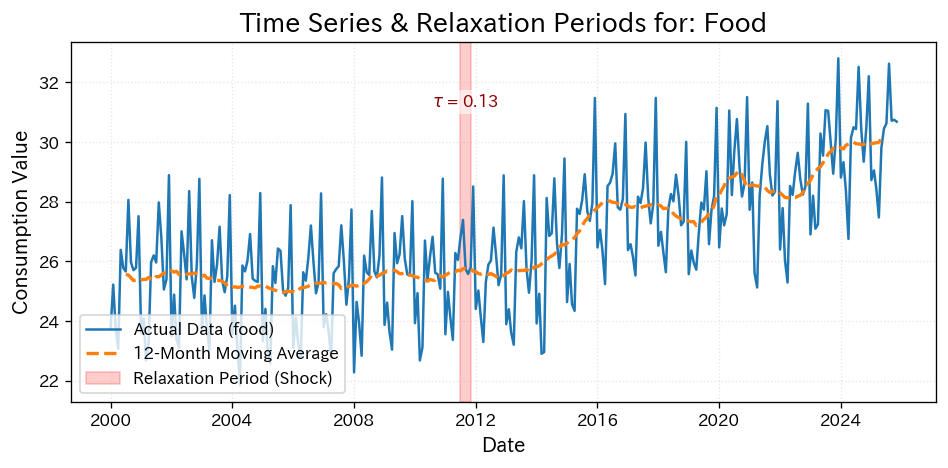

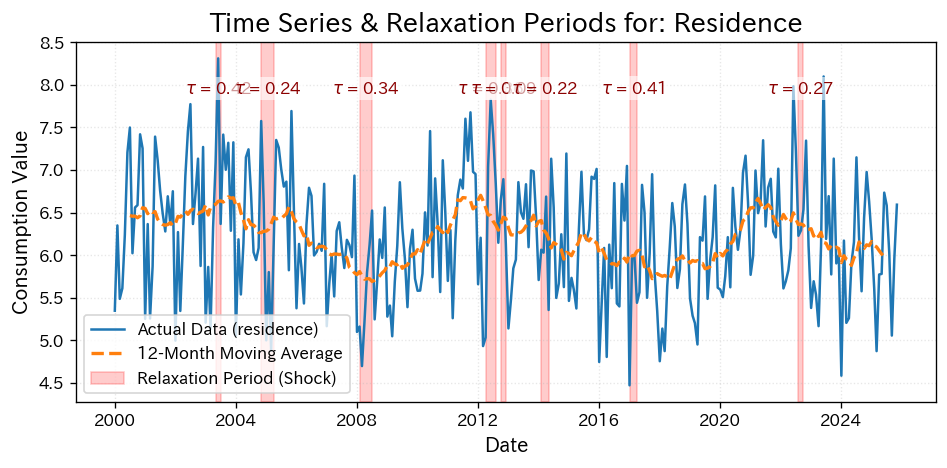

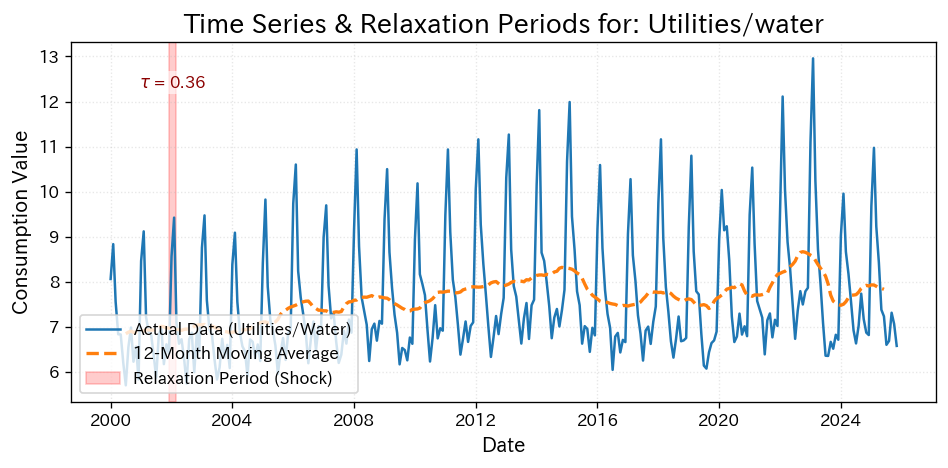

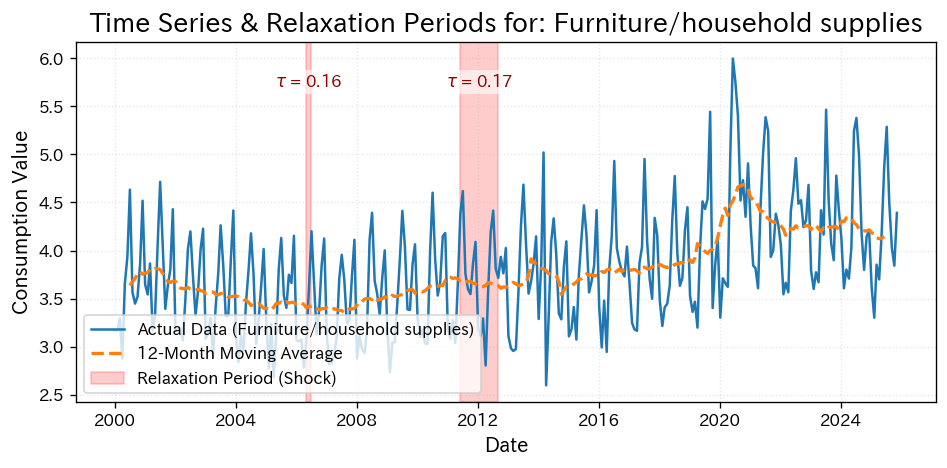

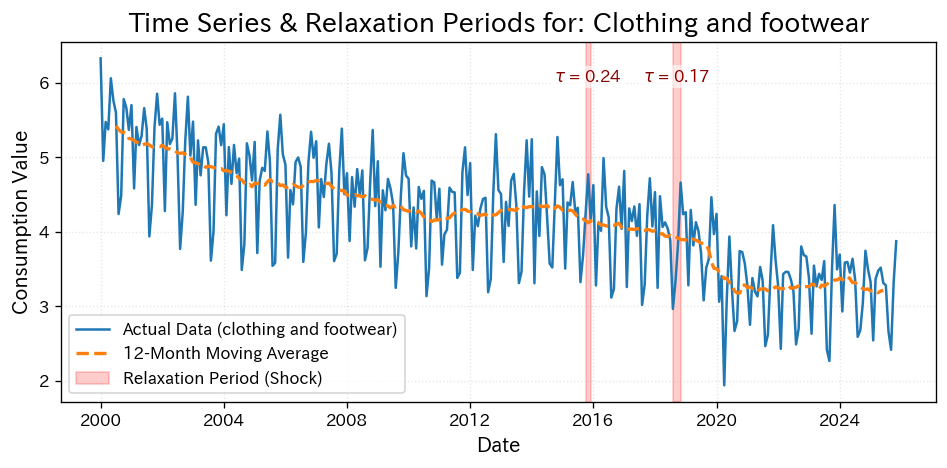

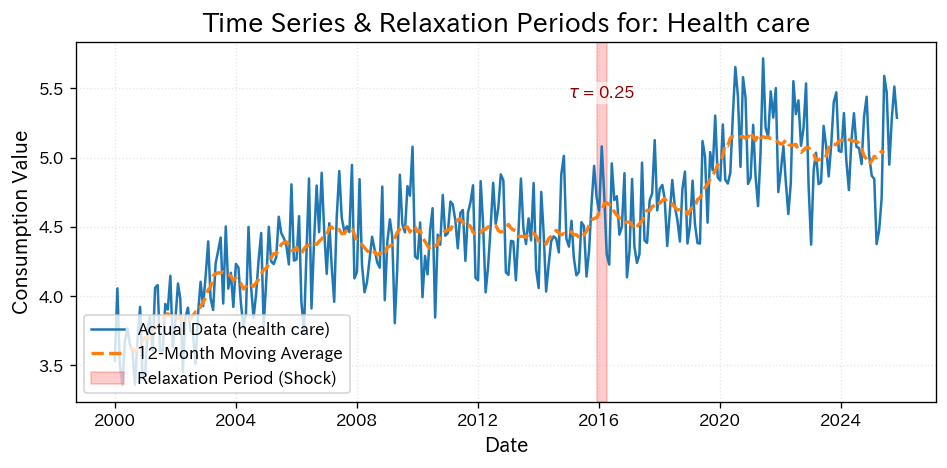

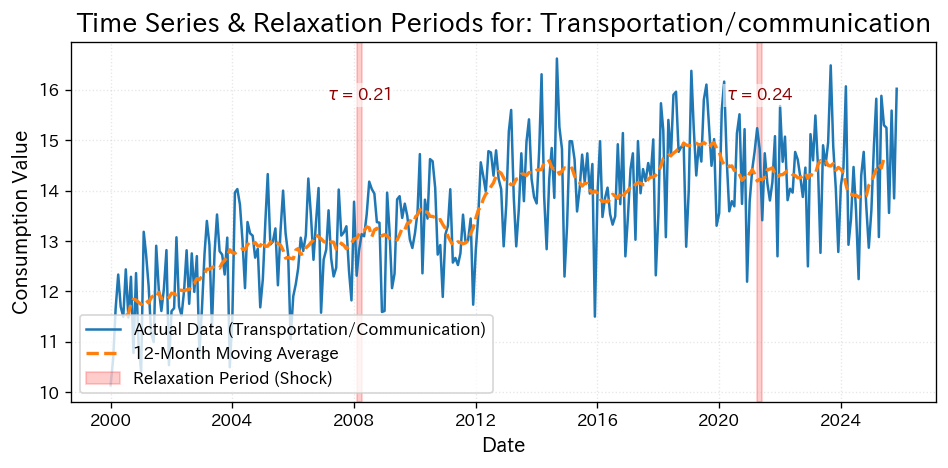

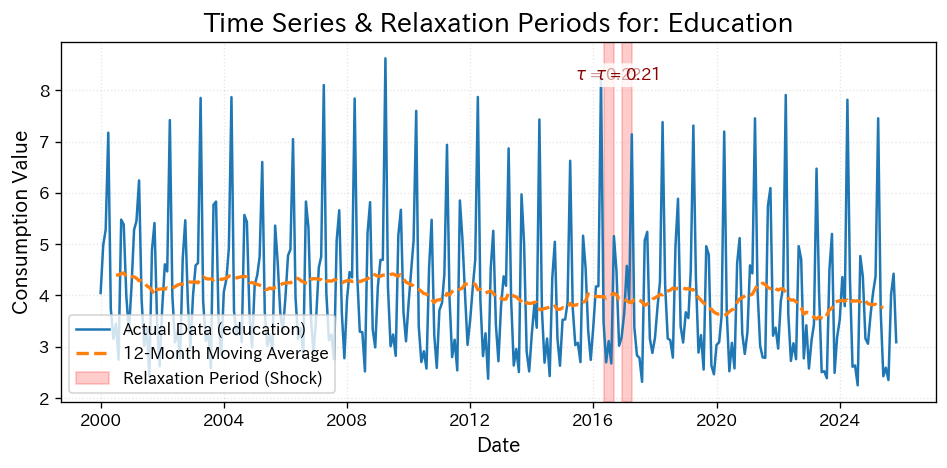

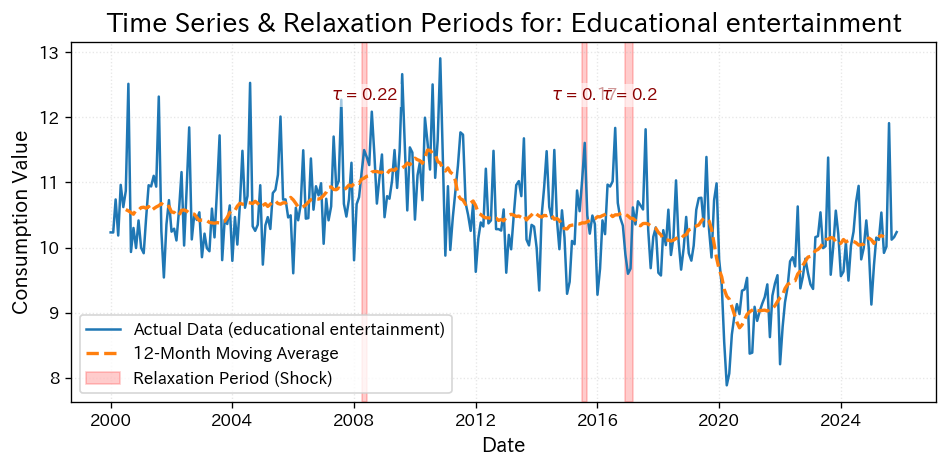

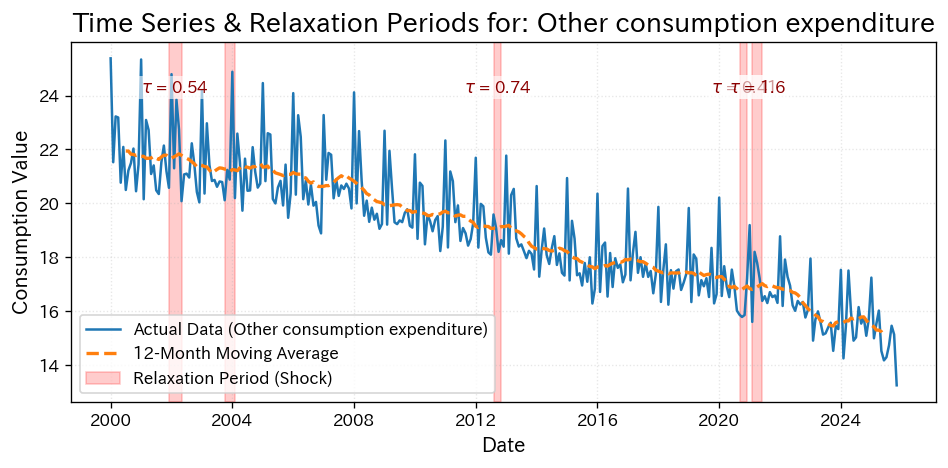

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_results_with_ax(df_clean, final_df, category):
    """
    Visualize the actual time series, moving average, and shock/relaxation 
    periods for a specific category using the calculated final_df.
    """
    # 1. Prepare the original time series data
    df = df_clean.copy()
    if 'Item' in df.columns:
        df['Item'] = pd.to_datetime(df['Item'])
        df.set_index('Item', inplace=True)
    
    # Ensure the index is DatetimeIndex just in case
    df.index = pd.to_datetime(df.index)
        
    actual = df[category]
    # Calculate the 12-month centered moving average (baseline)
    ma = actual.rolling(window=12, center=True).mean()
    
    # 2. Filter the results dataframe for the target category
    # Make a copy to avoid SettingWithCopyWarning
    cat_results = final_df[final_df['Category'] == category].copy() 
    
    # 3. Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
    
    # Plot Actual Data
    ax.plot(actual.index, actual, label=f'Actual Data ({category})', 
            color='#1f77b4', linewidth=1.5)
    
    # Plot Moving Average
    ax.plot(ma.index, ma, label='12-Month Moving Average', 
            color='#ff7f0e', linestyle='--', linewidth=2)
    
    # 4. Highlight the shock/relaxation periods from final_df
    added_label = False # Flag to avoid duplicate legend entries
    
    for _, row in cat_results.iterrows():
        # Convert string dates back to datetime objects for plotting
        start_date = pd.to_datetime(row['Peak_Date'])
        end_date = pd.to_datetime(row['Return_Date'])
        tau_val = row['Relaxation_Time_tau']
        
        # Add legend label only for the first shaded area
        label = 'Relaxation Period (Shock)' if not added_label else ""
        
        # Draw the shaded region (vertical span)
        ax.axvspan(start_date, end_date, color='red', alpha=0.2, label=label)
        added_label = True
        
        # Optional: Annotate the tau value directly above the shaded area
        # Calculate the midpoint of the shaded area for text placement
        mid_date = start_date + (end_date - start_date) / 2
        # Place text slightly below the maximum y-value of the plot
        y_max = actual.max()
        
        if pd.notna(tau_val):
            ax.text(mid_date, y_max * 0.95, f'$\\tau$ = {tau_val}', 
                    horizontalalignment='center', 
                    color='darkred', 
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))
            
    # 5. Format the axes and figure
    ax.set_title(f'Time Series & Relaxation Periods for: {category.capitalize()}', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Consumption Value', fontsize=12)
    
    # Configure the legend
    ax.legend(loc='lower left', fontsize=10)
    
    # Add a subtle grid
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Adjust layout to prevent clipping
    fig.tight_layout()
    
    # Display the plot
    plt.show()

# ==========================================
# Example Usage:
# Assuming 'df_clean' is your original wide dataframe
# and 'final_df' is the dataframe output from the calculation step.
for category in final_df['Category'].unique():
    plot_results_with_ax(df_clean, final_df, category)

# ==========================================